
Feature_Engineering.ipynb
==============================
Feature selection and data preparation for model training.

Steps covered:
- Loaded cleaned freight dataset
- Analyzed feature correlations via heatmap and Random Forest importance
- Dropped low importance features (lat/lon, date parts, equipment columns)
- Applied time-based split (Train: Jan-Aug 2025 | Test: Sep-Oct 2025)
  to prevent future data leakage into training
- Scaled features using StandardScaler fitted on train only

Output:
- train_data.csv
- test_data.csv


#  import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# load dataset

In [5]:

df = pd.read_csv('../dataset/processed/cleaned_freight_data.csv')
print("Shape:", df.shape)
print(df.columns.tolist())
df.head()

Shape: (47038, 16)
['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'posted_rate', 'month', 'day_of_week', 'quarter', 'is_weekend', 'equip_Dry Van', 'equip_Flatbed', 'equip_Reefer']


,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate,month,day_of_week,quarter,is_weekend,equip_Dry Van,equip_Flatbed,equip_Reefer
0,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,0.95684,2.39595,645.41,1,2,1,0,True,False,False
1,38.09122,-76.78906,39.22317,-72.96710,280.5,17555.0,0.97623,2.43355,679.97,1,2,1,0,False,False,True
2,39.22317,-72.96710,44.30296,-87.52871,967.8,31721.0,1.00971,1.84491,1802.54,1,2,1,0,True,False,False
3,39.55328,-72.18051,34.84933,-86.28940,965.4,32333.0,0.94518,1.87712,1827.28,1,2,1,0,True,False,False
4,31.83025,-94.38343,35.29479,-88.08915,541.9,35183.0,0.98480,2.56300,1380.28,1,2,1,0,False,False,True


# correlation heatmap all numuric


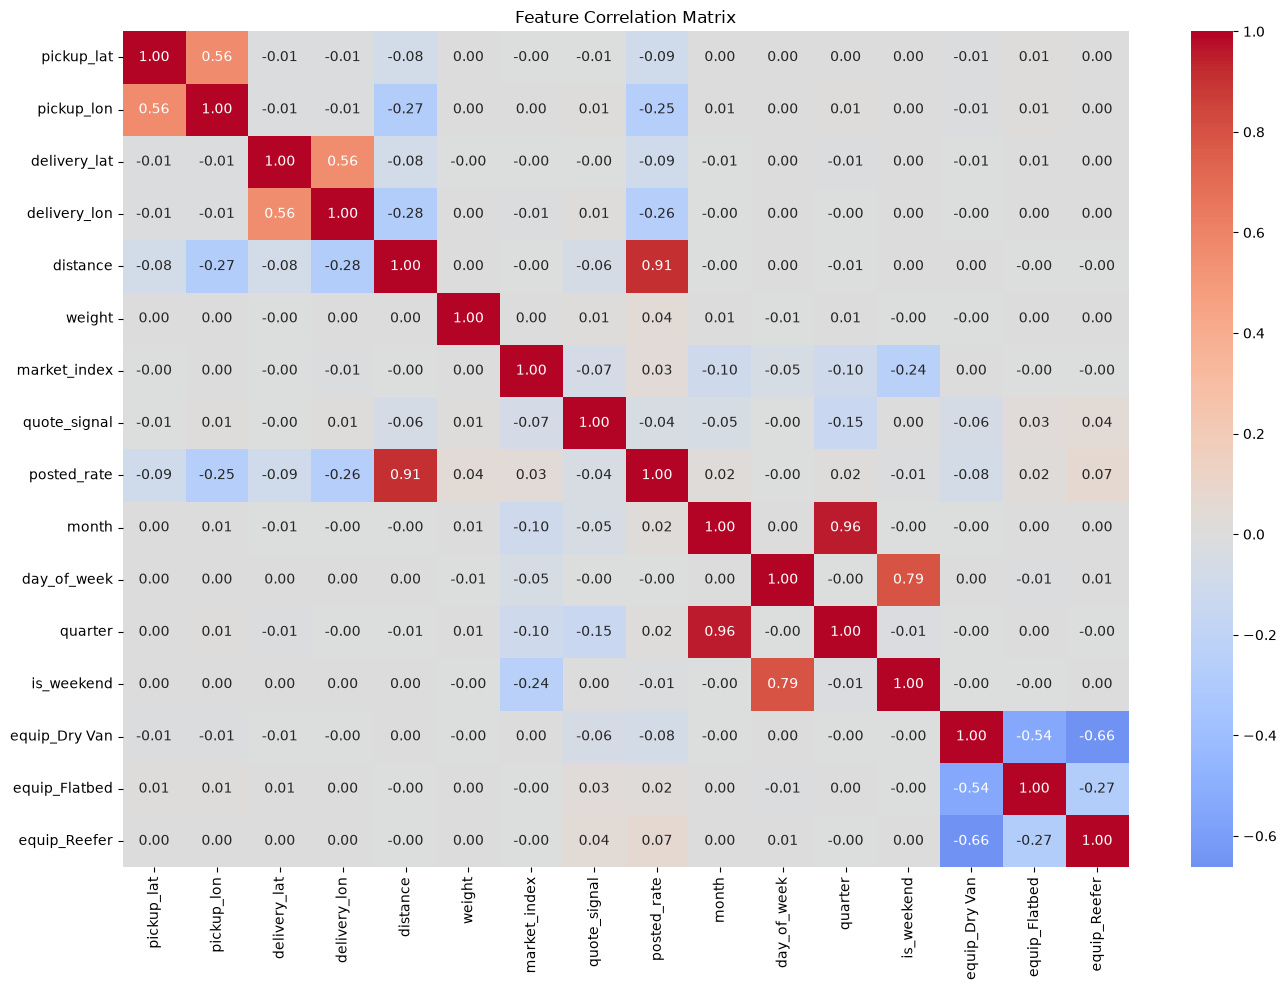

In [6]:
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

distance         0.908282
equip_Reefer     0.069461
weight           0.041589
market_index     0.033716
month            0.023280
equip_Flatbed    0.022192
quarter          0.017534
day_of_week     -0.003108
is_weekend      -0.007392
quote_signal    -0.039868
equip_Dry Van   -0.078066
pickup_lat      -0.091537
delivery_lat    -0.091595
pickup_lon      -0.254759
delivery_lon    -0.256771
Name: posted_rate, dtype: float64


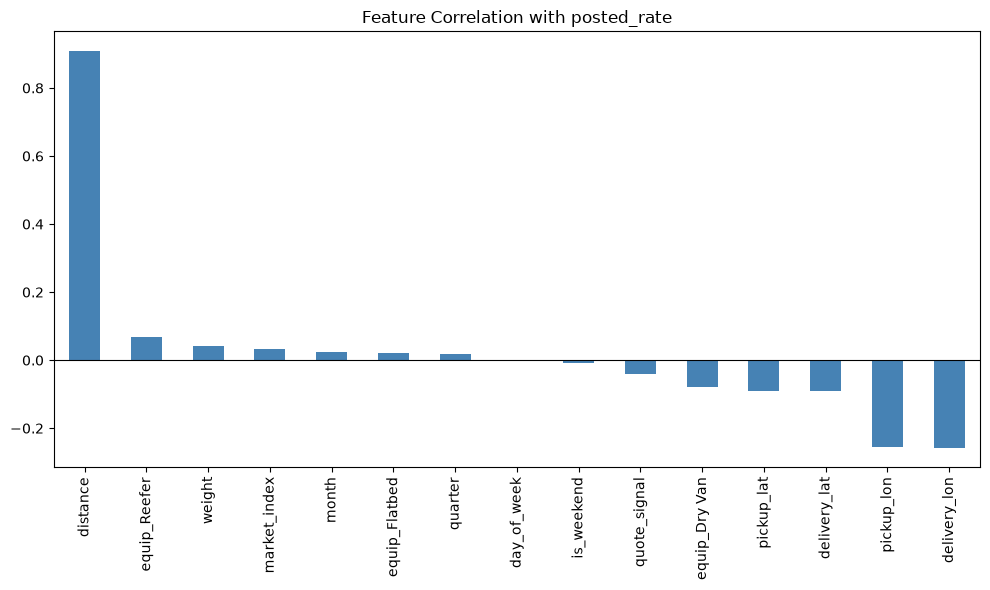

In [7]:
corr_target = df.corr()['posted_rate'].drop('posted_rate').sort_values(ascending=False)
print(corr_target)

plt.figure(figsize=(10, 6))
corr_target.plot(kind='bar', color='steelblue')
plt.title('Feature Correlation with posted_rate')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# chi-square test for encoded categorical columns

In [8]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

# chi2 requires non-negative values
cat_cols = [c for c in df.columns if 'equip' in c]
X_cat = df[cat_cols]
y = df['posted_rate']

chi_scores, p_values = chi2(X_cat, y.astype(int))
chi_df = pd.DataFrame({'feature': cat_cols, 'chi2_score': chi_scores, 'p_value': p_values})
print(chi_df.sort_values('chi2_score', ascending=False))

         feature   chi2_score  p_value
1  equip_Flatbed  5087.811113      1.0
2   equip_Reefer  4989.082214      1.0
0  equip_Dry Van  2838.950894      1.0


# Feature importance via Random Forest

          feature  importance
4        distance    0.863689
7    quote_signal    0.032612
5          weight    0.024325
6    market_index    0.022603
0      pickup_lat    0.008505
12  equip_Dry Van    0.008038
2    delivery_lat    0.007707
3    delivery_lon    0.007473
1      pickup_lon    0.006717
8           month    0.006106
9     day_of_week    0.006036
10        quarter    0.002709
14   equip_Reefer    0.001462
11     is_weekend    0.001173
13  equip_Flatbed    0.000846


C:\Users\LAKSHAN\AppData\Local\Temp\ipykernel_23908\605811431.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


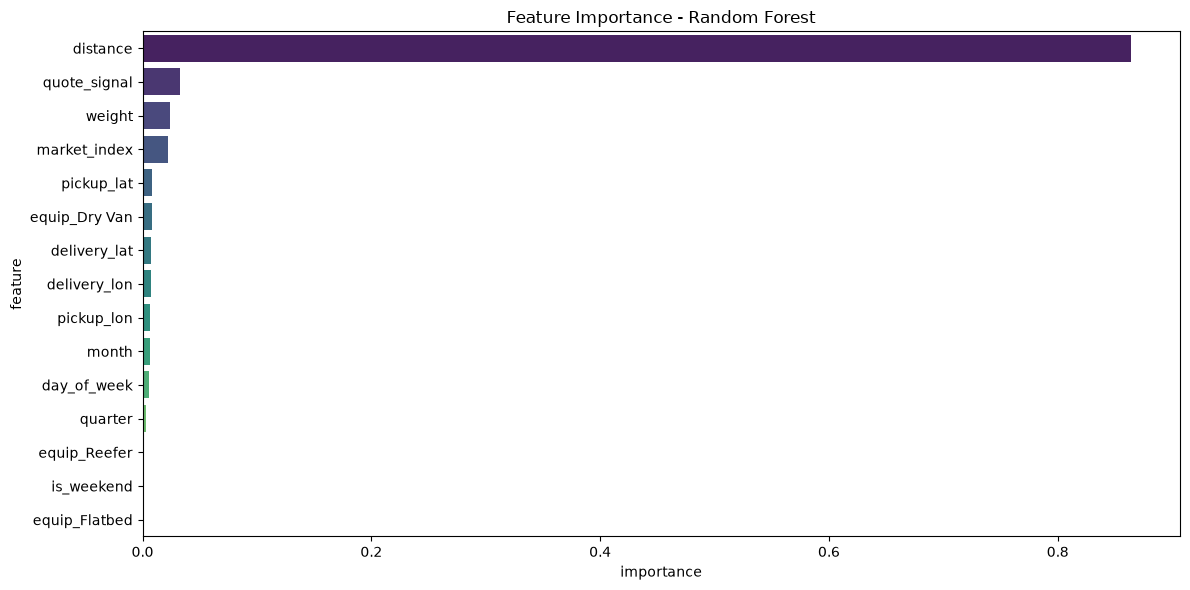

In [9]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['posted_rate'])
y = df['posted_rate']

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

# Drop low importance featuers

In [10]:
drop_cols = [
    'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
    'month', 'day_of_week', 'quarter', 'is_weekend',
    'equip_Dry Van', 'equip_Flatbed', 'equip_Reefer'
]

df_selected = df.drop(columns=drop_cols)
print("Final features:", df_selected.columns.tolist())
print("Shape:", df_selected.shape)

Final features: ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']
Shape: (47038, 5)


In [11]:
df_selected.head()

,distance,weight,market_index,quote_signal,posted_rate
0,274.3,30658.0,0.95684,2.39595,645.41
1,280.5,17555.0,0.97623,2.43355,679.97
2,967.8,31721.0,1.00971,1.84491,1802.54
3,965.4,32333.0,0.94518,1.87712,1827.28
4,541.9,35183.0,0.98480,2.56300,1380.28


# Prepare dataset for Training

In [12]:
# reload date raw data
df_raw = pd.read_csv('../dataset/train-test.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'])

print("Date range:", df_raw['date'].min(), "→", df_raw['date'].max())
print("Total months:", df_raw['date'].dt.to_period('M').nunique())
df_raw['date'].dt.to_period('M').value_counts().sort_index()

Date range: 2025-01-01 00:00:00 → 2025-10-31 00:00:00
Total months: 10


date
2025-01    4918
2025-02    4337
2025-03    5036
2025-04    4819
2025-05    4913
2025-06    4783
2025-07    4912
2025-08    4759
2025-09    4670
2025-10    4853
Freq: M, Name: count, dtype: int64

- Time-based split instead of random split
- Freight rates are time-dependent  random split would leak future market conditions
- into training, causing inflated performance that fails in real world.
- Train on past (Jan-Aug), predict future (Sep-Oct) mirrors real deployment.
- split_date = '2025-09-01'

In [13]:
df_raw['date'] = pd.to_datetime(df_raw['date'])

# define split point
split_date = '2025-09-01'

train_df = df_raw[df_raw['date'] < split_date]
test_df  = df_raw[df_raw['date'] >= split_date]

print("Train:", train_df.shape, "| Date range:", train_df['date'].min(), "→", train_df['date'].max())
print("Test: ", test_df.shape,  "| Date range:", test_df['date'].min(), "→", test_df['date'].max())
print(f"\nTrain %: {len(train_df)/len(df_raw)*100:.1f}%")
print(f"Test  %: {len(test_df)/len(df_raw)*100:.1f}%")

Train: (38477, 14) | Date range: 2025-01-01 00:00:00 → 2025-08-31 00:00:00
Test:  (9523, 14) | Date range: 2025-09-01 00:00:00 → 2025-10-31 00:00:00

Train %: 80.2%
Test  %: 19.8%


In [14]:
# Apply selected features on split
selected_features = ['distance', 'quote_signal', 'weight', 'market_index']
target = 'posted_rate'

X_train = train_df[selected_features]
y_train = train_df[target]

X_test = test_df[selected_features]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (38477, 4)
X_test:  (9523, 4)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print("Scaling done ")

Scaling done 


In [16]:
import joblib

# Save scaler for future real world predictions
joblib.dump(scaler, 'scaler.pkl')
print("Saved scaler.pkl")

# Save scaled arrays as dataframes with feature names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=selected_features)

# Add target back
X_train_scaled_df['posted_rate'] = y_train.values
X_test_scaled_df['posted_rate']  = y_test.values

X_train_scaled_df.to_csv('../dataset/processed/train_scaled.csv', index=False)
X_test_scaled_df.to_csv('../dataset/processed/test_scaled.csv',   index=False)

print("Saved train_scaled.csv:", X_train_scaled_df.shape)
print("Saved test_scaled.csv: ", X_test_scaled_df.shape)

Saved scaler.pkl
Saved train_scaled.csv: (38477, 5)
Saved test_scaled.csv:  (9523, 5)
